Let's begin by understanding the behavior of the distribution's tails, that is, of the extreme data points which represent very high or very low yardage gap plays. From previous experiments, we know that they exhibit pronounced "heavy tail" behavior. From this, we made up some hypotheses about statistical distributions that may be a good fit. We apply tests to judge the significance of such match, in order to determine the most suitable parametrization for each. 

In [6]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import math
import pickle
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold

In [7]:
def diagnostico_cauda(df, query_cond, coluna_target, threshold, refletir=False):
    if refletir:
        dados_cauda = threshold - df.query(query_cond)[coluna_target].values
    else:
        dados_cauda = df.query(query_cond)[coluna_target].values - threshold
    n_exemplos = len(dados_cauda)
    print(f"Total de exemplos na cauda: {n_exemplos}")
    if n_exemplos < 10:
        print("Few data")
        return

    candidates = {"GenPareto": stats.genpareto,
                "Exponential": stats.expon,
                "Weibull": stats.weibull_min,
                "Log-normal": stats.lognorm,}

    print(f"{'Distribution':20s} | {'KS Stat':7s} | {'p-value':7s} | {'AIC':8s} | Para")
    print("-" * 90)

    for name, dist in candidates.items():
        try:
            params = dist.fit(dados_cauda, floc=0)
            ks_stat, ks_p = stats.kstest(dados_cauda, dist.cdf, args=params)
            log_l = np.sum(dist.logpdf(dados_cauda, *params))
            k = len(params) - 1   #minus fixed loc
            aic = 2 * k - 2 * log_l
            p_str = ", ".join([f"{p:.4f}" for p in params if p != 0])
            print(f"{name:20s} | {ks_stat:.4f}  | {ks_p:.4f}  | {aic:.1f}  | ({p_str})")
        except Exception as e:
            print(f"Error fitting {name}: {e}")


In [9]:
df = pd.read_parquet("./data/nfl_train.parquet")
df_val_ext = pd.read_parquet("./data/nfl_test.parquet")  

#internal split for diagnosis (not used in the final test)
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)
split_idx = int(len(df_shuffled) * 0.86)
train_df = df_shuffled.iloc[:split_idx]
val_df = df_shuffled.iloc[split_idx:]
print(f"In Train: {len(train_df)} | In Val: {len(val_df)}")
print(f"Set Apart/Test Holdout: {len(df_val_ext)}")


In Train: 24153 | In Val: 3933
Set Apart/Test Holdout: 2921


In [10]:
print("RIGHT TAIL DIAGNOSIS (Yards > 15)")
THRES_RIGHT = 15
diagnostico_cauda(val_df, f"Yards > {THRES_RIGHT}", "Yards", THRES_RIGHT, refletir=False)

print("\DIAGNOSTIC OF THE LEFT TAIL (Yards < -3)")
THRES_LEFT = -3
diagnostico_cauda(val_df, f"Yards < {THRES_LEFT}", "Yards", THRES_LEFT, refletir=True)


RIGHT TAIL DIAGNOSIS (Yards > 15)
Total de exemplos na cauda: 192
Distribution         | KS Stat | p-value | AIC      | Para
------------------------------------------------------------------------------------------
GenPareto            | 0.1168  | 0.0097  | 1303.9  | (0.3189, 7.8948)
Exponential          | 0.1587  | 0.0001  | 1320.7  | (11.4062)
Weibull              | 0.1191  | 0.0079  | 1316.0  | (0.8763, 10.5573)
Log-normal           | 0.0859  | 0.1111  | 1282.5  | (1.1483, 5.8842)
\DIAGNOSTIC OF THE LEFT TAIL (Yards < -3)
Total de exemplos na cauda: 80
Distribution         | KS Stat | p-value | AIC      | Para
------------------------------------------------------------------------------------------
GenPareto            | 0.3307  | 0.0000  | 264.0  | (-0.3586, 2.6742)
Exponential          | 0.3954  | 0.0000  | 271.9  | (1.9875)
Weibull              | 0.2663  | 0.0000  | 245.5  | (1.6364, 2.2453)
Log-normal           | 0.3112  | 0.0000  | 222.8  | (0.5730, 1.6578)


<>:5: SyntaxWarning: invalid escape sequence '\D'
<>:5: SyntaxWarning: invalid escape sequence '\D'
/var/folders/qb/ldt_bc3j77969pkfrmpl2bbc0000gn/T/ipykernel_18146/701194645.py:5: SyntaxWarning: invalid escape sequence '\D'
  print("\DIAGNOSTIC OF THE LEFT TAIL (Yards < -3)")


Another important thing is to statistically determine the best points in which to cut the data into three distributions. We could set it as a learning parameter, but I fear we don't have enough data to ensure training stability with random initialization. Thus, we will determine best candidates beforehand, statistically, by analyzing the mean excesses. Parameters will be initialized with those values and we expect learning adjustaments to be small. On the threshold X mean excess plot, we expect to observe a linear upward trend above a certain point, which mathematically is the best candidate for our splitting threshold. 

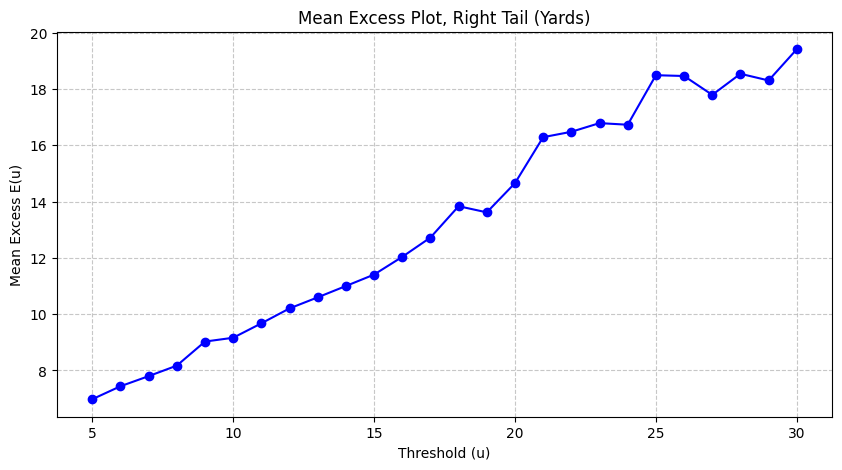

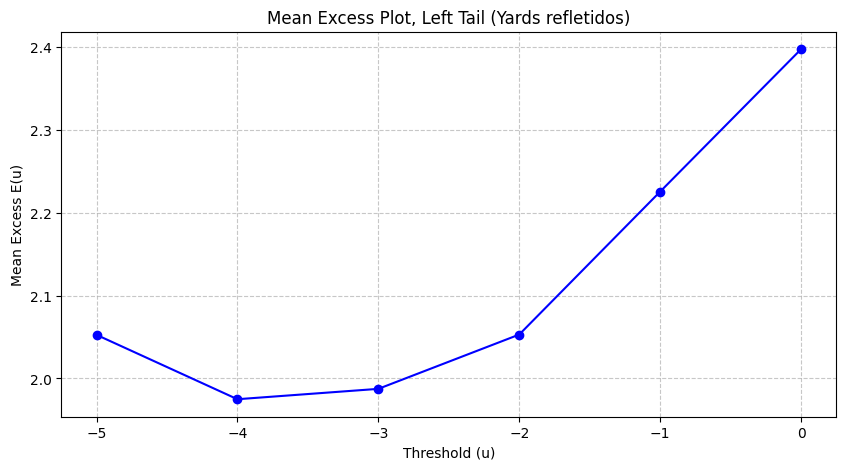

In [11]:
def plot_mean_excess(dados_originais, thresholds_testados, titulo, refletir=False):
    mean_excess_values = []
    thresholds_validos = []

    for u in thresholds_testados:
        if refletir:
            dados_t    = -dados_originais
            excedencias = dados_t[dados_t > u] - u
        else:
            excedencias = dados_originais[dados_originais > u] - u

        if len(excedencias) > 15:
            mean_excess_values.append(np.mean(excedencias))
            thresholds_validos.append(u)

    eixo_x = [-u for u in thresholds_validos] if refletir else thresholds_validos

    plt.figure(figsize=(10, 5))
    plt.plot(eixo_x, mean_excess_values, marker="o", linestyle="-", color="b")
    plt.title(titulo)
    plt.xlabel("Threshold (u)")
    plt.ylabel("Mean Excess E(u)")
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.show()

    return pd.DataFrame({"Threshold": eixo_x, "Mean_Excess": mean_excess_values})

df_right = plot_mean_excess(
    val_df["Yards"].values,
    np.arange(5, 31, 1),
    "Mean Excess Plot, Right Tail (Yards)",
    refletir=False,)

df_left = plot_mean_excess(
    val_df["Yards"].values,
    np.arange(0, 11, 1),
    "Mean Excess Plot, Left Tail (Yards refletidos)",
    refletir=True,)


Based on statistical diagnosis:

- **Left tail:** Reflected Weibull (smaller AIC, ξ < 0 in GPD indicates finite support — Weibull naturally captures this)
- **Right tail:** GPD with ξ > 0 (heavy tail, theoretical justification by the Pickands-Balkema-de Haan Theorem)
- **Initial thresholds:** u_left = −2, u_right = 16 (adjustable ±3 yards by the net)

Having set the distributions, our model will function as follows: a core MLP network will predict the entire probability landscape  play using a three-part, hybrid architecture. On the center, where we have more data available, CDF will be inferred via in-bin frequency accumulation. Thus, since it covers 18 yards, its output will be 19 neurons, one for the frequency of each yard bin. On the right tail, we will parametrically fit a GDP distribution. The output layer will have two neurons, one for each parameter that defines the distribution. Similar thing will be done with the left tail: we will parametrically fit a reflected Weibull distribution, and two neurons will output the respective parameters that define it. The u_left and u_right thresholds (splitting points we determined the statistical best candidates) are adaptive per play but restricted to varying ±3 yards around the initial values via tanh to avoid instabilties. 

In [131]:
class SplicedWeibullParetoHead(nn.Module):
    def __init__(self, input_dim=256, u_left_init=-2.0, u_right_init=16.0):
        super().__init__()
        self.u_left_base  = u_left_init
        self.u_right_base = u_right_init
        #[u_left_init, u_right_init]
        self.K = int(u_right_init - u_left_init) + 1   # = 19
        # outputs:
        # K logits of the central histogram
        # 2 left Weibull curves: log_scale, log_shape
        # 2 right GPD curves: log_sigma, xi
        # 3 logits of the mixing weights (p_left, p_center, p_right)
        # 2 adaptive offsets of the thresholds (u_left, u_right)
        self.total_outputs = self.K + 2 + 2 + 3 + 2
        self.fc_out = nn.Linear(input_dim, self.total_outputs)

    def forward(self, x):
        out = self.fc_out(x)  # [B, total_outputs]

        idx = 0
        logits_center = out[:, idx : idx + self.K]; idx += self.K
        log_scale_left = out[:, idx : idx + 1]; idx += 1
        log_shape_left = out[:, idx : idx + 1]; idx += 1
        log_sigma_right = out[:, idx : idx + 1]; idx += 1
        xi_right = out[:, idx : idx + 1]; idx += 1
        logits_weights = out[:, idx : idx + 3]; idx += 3
        offset_left = out[:, idx : idx + 1]; idx += 1
        offset_right = out[:, idx : idx + 1]; idx += 1

        #Weights of the three regions that add up to 1
        probs_regions = torch.softmax(logits_weights, dim=-1)  #[B, 3]
        p_left = probs_regions[:, 0:1]   #[B, 1]
        p_center = probs_regions[:, 1:2]
        p_right = probs_regions[:, 2:3]
        #Left Weibull parameters both positive
        scale_left = torch.exp(log_scale_left).clamp(min=0.01, max=50.0)
        shape_left = torch.exp(log_shape_left).clamp(min=0.1,  max=10.0)
        #Right GPD parameters
        sigma_right = torch.exp(log_sigma_right).clamp(min=0.01, max=50.0)
        xi_right = xi_right.clamp(min=0.001, max=1.0)   
        #Adaptive thresholds ±3 yards
        u_left_pred = self.u_left_base  + 3.0 * torch.tanh(offset_left)   # [B, 1]
        u_right_pred = self.u_right_base + 3.0 * torch.tanh(offset_right)  # [B, 1]

        return {
            "logits_center": logits_center,
            "p_left": p_left,
            "p_center": p_center,
            "p_right": p_right,
            "weibull_scale_left": scale_left,
            "weibull_shape_left": shape_left,
            "gpd_sigma_right": sigma_right,
            "gpd_xi_right": xi_right,
            "u_left_pred": u_left_pred,
            "u_right_pred": u_right_pred,}


This function will build the CDF from the three split distributions. CDF's calculated conditionally across three mutually exclusive regions based on where the target yardage $X$ falls relative to the play's dynamic thresholds ($u_{\text{left}}$ and $u_{\text{right}}$). For the left tail, it reflects the negative yardage space using $u_{\text{left}} - X$, calculates the survival probability, and scales it by the left region weight ($p_{\text{left}}$). In the center, it accumulates the probabilities of a discrete 1-yard binned histogram. It takes the total probability mass of the left tail ($p_{\text{left}}$) as a starting baseline, and adds the cumulative sum of the softmax-activated center logits up to the target yardage index, scaled by the center region weight. On the right tail, it starts with the full probability mass of both the left and center regions.To this, it adds the GPD cumulative probability evaluated on the excess yards ($X - u_{\text{right}}$), scaled by the right region weight ($p_{\text{right}}$).

In [132]:
def calcular_spliced_cdf(preds, y_bins, temperature=5.0):
# Calculates the analytical spliced CDF for a grid of 199 bins.
# Parameters
# preds : dictionary returned by SplicedWeibullParetoHead.forward()
# y_bins : Tensor [199] with values from -99 to +99
# temperature : smoothness of the sigmoid transition between regions (default 5.0)
    
    y = y_bins.float().unsqueeze(0)   #[1, 199] broadcast with [B, 1]
    u_l = preds["u_left_pred"]  #[B, 1]
    u_r = preds["u_right_pred"]  #[B, 1]
    p_l = preds["p_left"] #[B, 1]
    p_c = preds["p_center"] #[B, 1]
    p_r = preds["p_right"] #[B, 1]

    #smooth transition gates
    # gate_left → 1 when y << u_l (we are in the left tail)
    # gate_right → 1 when y >> u_r (we are in the right tail)
    gate_left = torch.sigmoid(temperature * (u_l - y))   #[B, 199]
    gate_right = torch.sigmoid(temperature * (y - u_r))   #[B, 199]
    gate_center = (1.0 - gate_left) * (1.0 - gate_right)  #[B, 199]

    #Left Tail Reflected Weibull 
    # When y < u_l, excess = u_l - y > 0
    # CDF of the reflected Weibull: P(Y <= y) = exp(-(excess/scale)^shape)
    # (as y falls, the cumulative probability falls towards 0)
    scale_l = preds["weibull_scale_left"]   #[B, 1]
    shape_l = preds["weibull_shape_left"]   #[B, 1]
    excesso_esq = torch.clamp(u_l - y, min=0.0)
    cdf_weibull = torch.exp(-torch.pow(excesso_esq / scale_l + 1e-8, shape_l))
    cdf_left_region = p_l * cdf_weibull #[B, 199]

    # GDP Right Tail 
    # When y > u_r, excess = y - u_r > 0
    # CDF GPD: 1 - (1 + ξ·excess/σ)^(-1/ξ)
    sigma_r = preds["gpd_sigma_right"]   # [B, 1]
    xi_r = preds["gpd_xi_right"]      # [B, 1]
    excesso_dir = torch.clamp(y - u_r, min=0.0)
    gpd_base = 1.0 + xi_r * excesso_dir / sigma_r
    gpd_base = torch.clamp(gpd_base, min=1e-6)
    cdf_gpd_pure = 1.0 - torch.pow(gpd_base, -1.0 / xi_r)
    #The right region starts at (p_left + p_center) and goes to 1
    cdf_right_region = (p_l + p_c) + p_r * cdf_gpd_pure   # [B, 199]

    # Center discrete histogram
    # K bins from u_left_init to u_right_init inclusive; evaluated via interpolation
    #Linear distribution of the cumulative softmax CDF
    K  = preds["logits_center"].shape[1]
    probs_c = torch.softmax(preds["logits_center"], dim=-1)   # [B, K]
    cdf_c= torch.cumsum(probs_c, dim=-1)                   # [B, K]  (0 → 1)
    u_left_base  = -2.0 
    u_right_base = 16.0
    bin_values = torch.linspace(u_left_base, u_right_base, K,
                                device=y_bins.device)        

    # Bilinear interpolation: for each y in y_bins, find the position in the K bins
    # y shape [1, 199], bin_values shape [K]
    # Result: cdf_center_interp shape [B, 199]
    y_exp = y.unsqueeze(2) #[1, 199, 1]
    bv_exp = bin_values.view(1, 1, K) #[1, 1, K]
    cdf_c_exp = cdf_c.unsqueeze(1) #[B, 1, K]

    # Weight of each bin: triangular (hat) width 2
    dist = torch.abs(y_exp - bv_exp)         
    weights = torch.clamp(1.0 - dist, min=0.0)  
    w_sum = weights.sum(dim=2, keepdim=True).clamp(min=1e-8)
    weights = weights / w_sum                   
    cdf_center_interp = (cdf_c_exp * weights).sum(dim=2) 

    #Scales the center's contribution by p_center and shifts it by the offset of p_left.
    cdf_center_region = p_l + p_c * cdf_center_interp    
    # combine via gating
    cdf_final = (gate_left  * cdf_left_region
               + gate_center * cdf_center_region
               + gate_right * cdf_right_region)          

    #Ensure [0, 1] and monotonicity
    cdf_final = torch.clamp(cdf_final, 0.0, 1.0)
    cdf_final = torch.cummax(cdf_final.cpu(), dim=1).values.to(cdf_final.device)

    return cdf_final 


In [133]:
def calcular_loss_crps(cdf_pred, y_true, clip_min=-30, clip_max=50):
    y_true = torch.clamp(y_true, clip_min, clip_max)
    y_bins = torch.arange(-99, 100, device=cdf_pred.device).float()
    cdf_true = (y_bins[None, :] >= y_true[:, None]).float()
    return torch.mean((cdf_pred - cdf_true) ** 2)

Now, this class will merge the pre trained mlp with the new head. We have three fully connected (nn.Linear) layers compressing input downwards ($N \to 512 \to 512 \to 256$), with LayerNorm and Elu and Dropout. 

In [134]:
class SplicedNFLModel(nn.Module):
#Pre-trained MLP body coupled to a Spliced Weibull-Pareto printhead.
#The body must project to 256 dimensions (without the final layer of 199 outputs).
    def __init__(self, mlp_body, input_dim=256):
        super().__init__()
        self.body = mlp_body
        self.head = SplicedWeibullParetoHead(input_dim=input_dim)

    def forward(self, x):
        return self.head(self.body(x))


In [ ]:
def construir_corpo_mlp(input_features, dropout=0.2):
    #Rebuilds the MLP body (without the last linear layer of 199 outputs) we had trained bf
    return nn.Sequential(
        nn.Linear(input_features, 512), nn.LayerNorm(512), nn.ELU(), nn.Dropout(dropout),
        nn.Linear(512, 512), nn.LayerNorm(512), nn.ELU(), nn.Dropout(dropout),
        nn.Linear(512, 256), nn.LayerNorm(256), nn.ELU(),)

In [ ]:
def carregar_corpo_pretreinado(input_features, path_pt, dropout=0.2):
    #Loads the weights from the pre-trained model (nfl_mlp_base_full.pt) into the body
    # the .pt was saved with the final layer Linear(256, 199) included so use strict=False to ignore the keys that don't exist in the body
    corpo = construir_corpo_mlp(input_features, dropout)
    state = torch.load(path_pt, map_location="cpu")
    body_state = {}
    for k, v in state.items():
        if k.startswith("net.12"):
            continue
        new_key = k.replace("net.", "")
        body_state[new_key] = v

    missing, unexpected = corpo.load_state_dict(body_state, strict=False)
    print(f"Loaded. Missing:(esperado — cabeça nova): {len(missing)}")
    print(f"Unknown: {unexpected}")
    return corpo

In [ ]:
def preparar_dados(df_train, df_val):
    drop_cols = ["PlayId", "GameId", "Yards"]
    feature_cols = [c for c in df_train.columns if c not in drop_cols]
    pos_cols = [c for c in feature_cols if "Position" in c]
    le = LabelEncoder()
    le.fit(pd.concat([df_train[c] for c in pos_cols]).fillna("UNK"))

    def encode(df):
        df = df.copy()
        for col in pos_cols:
            df[col] = df[col].fillna("UNK").apply(
                lambda x: le.transform([x])[0] if x in le.classes_ else 0)
        return df.fillna(0.0)

    df_train_enc = encode(df_train)
    df_val_enc = encode(df_val)
    X_train = df_train_enc[feature_cols].values.astype(np.float32)
    X_val = df_val_enc[feature_cols].values.astype(np.float32)
    y_train = df_train["Yards"].values.astype(np.float32)
    y_val = df_val["Yards"].values.astype(np.float32)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    return X_train, y_train, X_val, y_val, scaler, le, feature_cols

In [ ]:
def get_y_flip_cols(feature_cols):
    keywords = ["_Y_rel", "_Sy", "_Ori_sin", "_Dir_sin"]
    return [i for i, c in enumerate(feature_cols) if any(c.endswith(k) for k in keywords)]

In [135]:
class PlayDataset(Dataset):
    def __init__(self, X, y, y_flip_cols=None, is_train=True):
        self.is_train = is_train
        self.flip_idx = list(y_flip_cols) if y_flip_cols else []
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        y = self.y[idx]
        if self.is_train and torch.rand(1).item() > 0.5:
            x[self.flip_idx] = -x[self.flip_idx]
        return x, y


In [ ]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"{device}")

In [136]:
EPOCHS = 52
BATCH_SIZE = 52
LR_BODY = 1e-4
LR_HEAD = 1e-3
SEED = 21
torch.manual_seed(SEED)

X_train, y_train, X_val, y_val, scaler, le, feature_cols = preparar_dados(df, df_val_ext)
n_features  = X_train.shape[1]
y_flip_cols = get_y_flip_cols(feature_cols)
print(f"Features: {n_features} | C flip Y: {len(y_flip_cols)}")

train_loader = DataLoader(PlayDataset(X_train, y_train, y_flip_cols=y_flip_cols, is_train=True), batch_size=BATCH_SIZE, shuffle=True, generator=torch.Generator().manual_seed(SEED))
val_loader = DataLoader(PlayDataset(X_val, y_val, y_flip_cols=y_flip_cols, is_train=False),batch_size=BATCH_SIZE, shuffle=False)

corpo = carregar_corpo_pretreinado(n_features, "nfl_mlp_base_full.pt")
model = SplicedNFLModel(mlp_body=corpo, input_dim=256).to(device)

optimizer = optim.AdamW([{"params": model.body.parameters(), "lr": LR_BODY}, {"params": model.head.parameters(), "lr": LR_HEAD},
], weight_decay=1e-4)

scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-4)
y_grid = torch.arange(-99, 100, dtype=torch.float32).to(device)

def train_epoch(model, loader, optimizer):
    model.train()
    total = 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        preds = model(X_b)
        cdf = calcular_spliced_cdf(preds, y_grid)
        loss = calcular_loss_crps(cdf, y_b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total += loss.item() * len(X_b)
    return total / len(loader.dataset)


def eval_epoch(model, loader):
    model.eval()
    all_cdfs, all_y = [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            preds = model(X_b.to(device))
            cdf = calcular_spliced_cdf(preds, y_grid)
            all_cdfs.append(cdf.cpu())
            all_y.append(y_b)
    cdfs = torch.cat(all_cdfs).numpy()
    y_true = torch.cat(all_y).numpy()
    y_bins = np.arange(-99, 100, dtype=np.float32)
    cdf_true = (y_bins[None, :] >= y_true[:, None]).astype(np.float32)
    return float(np.mean((cdfs - cdf_true) ** 2)), cdfs, y_true

Dispositivo: mps
Features: 344 | Colunas flip Y: 88
Pesos carregados. Faltando (esperado — cabeça nova): 0
Inesperados: []
Época 01/52 | LR body: 5.0e-05 | LR head: 3.0e-03 | Train: 0.01287 | Val CRPS: 0.01250 ✓
Época 10/52 | LR body: 5.4e-05 | LR head: 2.7e-03 | Train: 0.01252 | Val CRPS: 0.01254
Época 20/52 | LR body: 6.6e-05 | LR head: 2.1e-03 | Train: 0.01226 | Val CRPS: 0.01263
Época 30/52 | LR body: 8.1e-05 | LR head: 1.2e-03 | Train: 0.01194 | Val CRPS: 0.01287
Época 40/52 | LR body: 9.4e-05 | LR head: 4.6e-04 | Train: 0.01173 | Val CRPS: 0.01281
Época 50/52 | LR body: 1.0e-04 | LR head: 1.1e-04 | Train: 0.01144 | Val CRPS: 0.01307
Época 52/52 | LR body: 1.0e-04 | LR head: 1.0e-04 | Train: 0.01138 | Val CRPS: 0.01306

>> Melhor Val CRPS: 0.01250
>> Baseline anterior: 0.01248
Modelo salvo: nfl_spliced_model_3.pt


In [ ]:
best_val = float("inf")
best_state = None

for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, optimizer)
    val_crps, cdfs_val, y_val_np = eval_epoch(model, val_loader)
    scheduler.step()
    lr_body = optimizer.param_groups[0]["lr"]
    lr_head = optimizer.param_groups[1]["lr"]
    if val_crps < best_val:
        best_val = val_crps
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    if epoch % 10 == 0 or epoch == 1 or epoch == EPOCHS:
        print(f"Epoch {epoch:02d}/{EPOCHS} | LR body: {lr_body:.1e} | LR head: {lr_head:.1e} | "
              f"Train: {train_loss:.5f} | Val CRPS: {val_crps:.5f}"
              + (" ✓" if val_crps == best_val else ""))

print(f"\n>> Best Val CRPS: {best_val:.5f}")
model.load_state_dict(best_state)
_, cdfs_val_base, y_val_np = eval_epoch(model, val_loader)

To improve tail's fit, we will add beta calibration on top of the output. We noticed from previous experiments and improved precision performance on the tails. With beta cal, "uncalibrated probabilities" ($p$) from the model's output are transformed logistically via $z = a \cdot \ln(p) - b \cdot \ln(1 - p) + c$. A simple optimization model (a logistic regression classifier in this case) is then trained on $z$ to find the optimal parameters $a$, $b$, and $c$ that minimize log-loss against the actual binary outcomes. This mapping shifts and scales the original spectrum, ensuring that a predicted probability matches its true objective real-world success rate.

In [137]:
def aplicar_beta_calibration_6fold(cdfs_pred, y_true, C=1.0):
    if torch.is_tensor(cdfs_pred):
        cdfs_pred = cdfs_pred.detach().cpu().numpy()
    if torch.is_tensor(y_true):
        y_true = y_true.detach().cpu().numpy()

    N, B = cdfs_pred.shape
    y_bins = np.arange(-99, 100, dtype=np.float32)
    cdf_calibrada = np.zeros_like(cdfs_pred)

    kf = KFold(n_splits=6, shuffle=True, random_state=42)
    print("Beta Calibration 6-Fold CV")

    for fold, (cal_idx, eval_idx) in enumerate(kf.split(cdfs_pred)):
        for b in range(B):
            p_cal= cdfs_pred[cal_idx, b]
            p_eval = cdfs_pred[eval_idx, b]
            y_bin = (y_true[cal_idx] <= y_bins[b]).astype(int)
            eps = 1e-7
            p_cal_c = np.clip(p_cal,  eps, 1 - eps)
            p_eval_c = np.clip(p_eval, eps, 1 - eps)
            X_cal = np.column_stack([np.log(p_cal_c),  np.log(1 - p_cal_c)])
            X_eval = np.column_stack([np.log(p_eval_c), np.log(1 - p_eval_c)])

            if len(np.unique(y_bin)) <= 1:
                cdf_calibrada[eval_idx, b] = p_eval
                continue

            clf = LogisticRegression(C=C, fit_intercept=True,max_iter=200, solver="lbfgs")
            clf.fit(X_cal, y_bin)
            cdf_calibrada[eval_idx, b] = clf.predict_proba(X_eval)[:, 1]

        for i in eval_idx:
            cdf_calibrada[i] = np.maximum.accumulate(cdf_calibrada[i])
            cdf_calibrada[i] = np.clip(cdf_calibrada[i], 0.0, 1.0)

        print(f"Fold {fold+1}/6")

    return cdf_calibrada


#apply
cdfs_val_calibradas = aplicar_beta_calibration_6fold(cdfs_val_base, y_val_np)


=== Beta Calibration 6-Fold CV ===
  Fold 1/6 ✓
  Fold 2/6 ✓
  Fold 3/6 ✓
  Fold 4/6 ✓
  Fold 5/6 ✓
  Fold 6/6 ✓


In [ ]:
def calcular_crps_np(cdfs, y_true):
    y_bins= np.arange(-99, 100, dtype=np.float32)
    cdf_true = (y_bins[None, :] >= y_true[:, None]).astype(np.float32)
    return float(np.mean((cdfs - cdf_true) ** 2))

In [138]:
def relatorio_desempenho(cdfs, y_true, label=""):
    y_bins = np.arange(-99, 100, dtype=np.float32)

    def crps_mask(cdfs, y_true, mask):
        if mask.sum() == 0:
            return float("nan")
        cdf_true = (y_bins[None, :] >= y_true[mask, None]).astype(np.float32)
        return float(np.mean((cdfs[mask] - cdf_true) ** 2))

    mask_neg = y_true < 0
    mask_curto = (y_true >= 0) & (y_true <= 5)
    mask_medio = (y_true > 5)  & (y_true <= 15)
    mask_longo = y_true > 15

    crps_global = calcular_crps_np(cdfs, y_true)

    print(f"\n{'='*55}")
    if label:
        print(f"  {label}")
    print(f"{'='*55}")
    print(f"global CRPS: {crps_global:.5f}")
    print(f"\n On each dist")
    print(f"Left Tail (negs)  (< 0):   n={mask_neg.sum():4d} | CRPS={crps_mask(cdfs, y_true, mask_neg):.5f}")
    print(f"Center (short)   (0 - 5):   n={mask_curto.sum():4d} | CRPS={crps_mask(cdfs, y_true, mask_curto):.5f}")
    print(f"Center (medium)  (6 - 15):   n={mask_medio.sum():4d} | CRPS={crps_mask(cdfs, y_true, mask_medio):.5f}")
    print(f"Right Tail (pos) (> 15):   n={mask_longo.sum():4d} | CRPS={crps_mask(cdfs, y_true, mask_longo):.5f}")
    
    print(f"\nLeft Tail Calibration")
    print(f"  {'Threshold':>10} | {'P(prev)':>8} | {'P(real)':>8} | {'Error':>8}")
    for t in [-1, -3, -5, -10]:
        idx = t + 99
        pred_prob = float(np.mean(cdfs[:, idx]))
        true_prob = float(np.mean(y_true <= t))
        print(f"yards <= {t:2d}  | {pred_prob:8.4f} | {true_prob:8.4f} | {pred_prob-true_prob:+8.4f}")

    print(f"\nRight Tail Calibration")
    print(f"  {'Threshold':>10} | {'P(prev)':>8} | {'P(real)':>8} | {'Error':>8}")
    for t in [10, 15, 20, 25, 30, 40]:
        idx = t + 99
        pred_prob = float(np.mean(1 - cdfs[:, idx]))
        true_prob = float(np.mean(y_true > t))
        print(f"yards > {t:2d}   | {pred_prob:8.4f} | {true_prob:8.4f} | {pred_prob-true_prob:+8.4f}")

    return crps_global


crps_sem_cal = relatorio_desempenho(cdfs_val_base,       y_val_np, "No calibration version")
crps_com_cal = relatorio_desempenho(cdfs_val_calibradas, y_val_np, "GDP + Reflected Weibull spliced model with Beta calibration")

print(f"\nImprovement: {crps_sem_cal - crps_com_cal:+.5f}")



  Spliced — SEM calibração
CRPS global: 0.01250  (baseline: 0.01248)

--- Por região ---
Negativos  (< 0):   n= 318 | CRPS=0.01638
Curtos   (0 - 5):   n=1874 | CRPS=0.00597
Médios  (6 - 15):   n= 611 | CRPS=0.01636
Longos    (> 15):   n= 118 | CRPS=0.08580

--- Calibração cauda direita ---
   Threshold |  P(prev) |  P(real) |     Erro
  yards > 10   |   0.0870 |   0.0880 |  -0.0009
  yards > 15   |   0.0355 |   0.0404 |  -0.0049
  yards > 20   |   0.0185 |   0.0195 |  -0.0011
  yards > 25   |   0.0101 |   0.0103 |  -0.0001
  yards > 30   |   0.0057 |   0.0072 |  -0.0015
  yards > 40   |   0.0019 |   0.0045 |  -0.0026

  Spliced — COM Beta calibration
CRPS global: 0.01248  (baseline: 0.01248)

--- Por região ---
Negativos  (< 0):   n= 318 | CRPS=0.01638
Curtos   (0 - 5):   n=1874 | CRPS=0.00573
Médios  (6 - 15):   n= 611 | CRPS=0.01678
Longos    (> 15):   n= 118 | CRPS=0.08687

--- Calibração cauda direita ---
   Threshold |  P(prev) |  P(real) |     Erro
  yards > 10   |   0.0880 |   

Final training on all available data (all nfl_train.parquet) and saving the model

In [139]:
y_bins_np = np.arange(-99, 100, dtype=np.float32)
eps = 1e-7
calibradores_finais = []

for b in range(199):
    p_pred = np.clip(cdfs_val_base[:, b], eps, 1 - eps)
    y_bin = (y_val_np <= y_bins_np[b]).astype(int)
    X_cal = np.column_stack([np.log(p_pred), np.log(1 - p_pred)])
    clfc= LogisticRegression(C=1.0, fit_intercept=True, max_iter=200, solver="lbfgs")
    if len(np.unique(y_bin)) > 1:
        clf.fit(X_cal, y_bin)
        calibradores_finais.append(clf)
    else:
        calibradores_finais.append(None)

with open("nfl_spliced_calibradores.pkl", "wb") as f:
    pickle.dump({"calibradores" : calibradores_finais,
        "crps_sem_cal" : crps_sem_cal,
        "crps_com_cal" : crps_com_cal,
        "scaler" : scaler,
        "label_encoder": le,
        "feature_cols" : feature_cols,
        "n_features" : n_features,
        "y_flip_cols" : y_flip_cols,}, f)

print(f"\n>> CRPS FINAL: {crps_com_cal:.5f}")

Treinando calibradores finais em todos os dados de validação...
Salvo: nfl_spliced_model_2.pt
Salvo: nfl_spliced_calibradores_2.pkl

>> CRPS FINAL (com Beta calibration, OOF honesto): 0.01248


Finally, Let's get that data we'd set apart for testing (nfl_test.parquet) which's never been used before and put the model to the test on it, so we obtain a (ideally) non biased CRPS metric

In [ ]:
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

with open("nfl_spliced_calibradores.pkl", "rb") as f:
    artefatos = pickle.load(f)

calibradores = artefatos["calibradores"]
scaler = artefatos["scaler"]
le = artefatos["label_encoder"]
feature_cols = artefatos["feature_cols"]
n_features = artefatos["n_features"]
pos_cols = [c for c in feature_cols if "Position" in c]
model = SplicedNFLModel(input_features=n_features).to(device)
model.load_state_dict(torch.load("nfl_spliced_model.pt", map_location=device))
df_test = pd.read_parquet("./entrega/data/nfl_test.parquet")
print(f"nfl_test: {len(df_test)} plays")

X_test = preparar_X(df_test, feature_cols, pos_cols, le, scaler)
y_test = df_test["Yards"].values.astype(np.float32)
test_loader = DataLoader(SimpleDataset(X_test, y_test), batch_size=256, shuffle=False)
y_grid = torch.arange(-99, 100, dtype=torch.float32).to(device)

cdfs_test, y_test_np = get_cdfs(model, test_loader, device, y_grid)
crps_sem = relatorio(cdfs_test, y_test_np, "Without calibration (nfl_test)")
cdfs_cal = aplicar_calibradores(cdfs_test, calibradores)
crps_com = relatorio(cdfs_cal, y_test_np, "Spliced with Beta calibration (nfl_test)")